# Лабораторная работа 6. Чёрный ящик и трансферируемость атак: transfer-based, score-based, decision-based методы

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 5**
 

**Среда:** Python, PyTorch, torchvision


## Цель работы
Закрепить методы построения adversarial-примеров в условиях ограниченного доступа к целевой модели и научиться сравнивать transfer-based, score-based и decision-based атаки по успешности, числу запросов и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- обучать суррогатную модель через запросы к оракулу и переносить на неё белоящичную атаку (transfer-based);
- реализовывать оценку градиента через запросы confidence-баллов методом конечных разностей (ZOO) и методом случайной выборки (NES);
- реализовывать decision-based атаку (Boundary Attack), работающую только с итоговой меткой класса;
- сравнивать три класса чёрно-ящичных атак по критерию «качество атаки / стоимость запросов» и обосновывать выбор метода под конкретный сценарий доступа к API.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Все атаки в этой работе взаимодействуют с целевой моделью только через специальный объект-оракул — прямой доступ к её параметрам и градиентам запрещён по условию задания (это имитирует реальный чёрный ящик).


## 0. Подготовка окружения

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torchvision import datasets, transforms

RANDOM_STATE = 90
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## Часть I. Целевая модель и оракул

**Задание:** загрузите MNIST, обучите CNN-классификатор (2 свёрточных слоя + полносвязный классификатор) — эта модель будет играть роль "чёрного ящика". Затем реализуйте класс-обёртку `QueryCounter`, через который ВСЕ последующие атаки должны обращаться к модели — прямой вызов `target_model(x)` в атаках запрещён, чтобы корректно считать число запросов.

In [2]:
# Загрузка MNIST
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

In [3]:
class TargetCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [4]:
# Обучение target_model
target_model = TargetCNN().to(device)

opt = torch.optim.Adam(
    target_model.parameters(),
    lr=0.001
)

crit = nn.CrossEntropyLoss()

for epoch in range(3):
    target_model.train()

    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        opt.zero_grad()

        outputs = target_model(images)
        loss = crit(outputs, labels)

        loss.backward()
        opt.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/3, "
        f"Loss: {avg_loss:.4f}"
    )

Epoch 1/3, Loss: 0.2355
Epoch 2/3, Loss: 0.0585
Epoch 3/3, Loss: 0.0411


In [5]:
# Clean accuracy
target_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = target_model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

clean_accuracy = 100 * correct / total

print(f"Clean accuracy: {clean_accuracy:.2f}%")

Clean accuracy: 98.70%


**Задание:** реализуйте класс `QueryCounter`, который считает число обращений к модели и предоставляет три уровня доступа:
- `logits(x)` — полные логиты (используется только для white-box эталона в Части V, НЕ для чёрно-ящичных атак);
- `probs(x)` — вероятности классов (softmax) — доступ уровня score-based;
- `label(x)` — только индекс предсказанного класса — доступ уровня decision-based.

Каждый вызов любого из трёх методов должен увеличивать счётчик `n_queries` на размер батча.

In [6]:
# QueryCounter
class QueryCounter:
    def __init__(self, model):
        self.model = model
        self.n_queries = 0

    def reset(self):
        self.n_queries = 0

    def logits(self, x):
        self.n_queries += x.size(0)

        self.model.eval()

        with torch.no_grad():
            return self.model(x)

    def probs(self, x):
        logits = self.logits(x)
        return torch.softmax(logits, dim=1)

    def label(self, x):
        logits = self.logits(x)
        return logits.argmax(dim=1)


oracle = QueryCounter(target_model)

## Часть II. Transfer-based атака

### 2.1. Обучение суррогатной модели через оракул

**Задание:** реализуйте суррогатную модель с архитектурой, отличной от целевой (например, полносвязная сеть вместо CNN), и обучите её по схеме Papernot et al.:

1. Соберите небольшой начальный набор данных (например, 20 примеров на класс) без использования меток из исходного датасета — размечайте их исключительно через `oracle.label(x)`.
2. Обучите суррогат на текущем наборе.
3. Постройте аугментацию данных по знаку якобиана суррогатной модели:

$ S_{\rho+1} = \left\{ \tilde{x} + \lambda \cdot \text{sign}\left(J_F[\tilde{O}(\tilde{x})]\right) : \tilde{x} \in S_\rho \right\} \cup S_\rho $

1. Разметьте новые примеры через `oracle.label` и повторите цикл несколько раундов (например, 5-6).

In [7]:
class SubstituteMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [30]:
oracle.reset()

n_seed_per_class = 20

candidate_images = []

for image, _ in train_dataset:
    candidate_images.append(image)

    if len(candidate_images) >= 300:
        break

candidate_images = torch.stack(candidate_images).to(device)

# Получаем метку класса для каждого изображения
oracle_labels_all = oracle.label(candidate_images)

substitute_data_list = []
substitute_labels_list = []

for class_id in range(10):
    indices = (oracle_labels_all == class_id).nonzero(as_tuple=True)[0]
    selected = indices[:n_seed_per_class]
    substitute_data_list.append(candidate_images[selected])
    substitute_labels_list.append(oracle_labels_all[selected])

substitute_data = torch.cat(substitute_data_list, dim=0)
oracle_labels = torch.cat(substitute_labels_list, dim=0)

print(f"Начальный набор: запросов к оракулу = {oracle.n_queries}")
print(f"Размер набора: {substitute_data.shape}")

Начальный набор: запросов к оракулу = 300
Размер набора: torch.Size([200, 1, 28, 28])


In [31]:
def jacobian_augmentation(model, x, labels, lam=0.1):
    x = x.clone().detach().requires_grad_(True)

    outputs = model(x)
    loss = F.cross_entropy(outputs, labels)

    grad = torch.autograd.grad(loss, x)[0]

    x_aug = x + lam * grad.sign()

    return torch.clamp(x_aug, 0, 1).detach()

In [32]:
substitute_model = SubstituteMLP().to(device)

opt_sub = torch.optim.Adam(
    substitute_model.parameters(),
    lr=0.001
)

crit_sub = nn.CrossEntropyLoss()

n_rounds = 6
current_data = substitute_data
current_labels = oracle_labels

for round_idx in range(n_rounds):
    # Обучение суррогатной модели
    substitute_model.train()

    opt_sub.zero_grad()

    outputs = substitute_model(current_data)
    loss = crit_sub(outputs, current_labels)

    loss.backward()
    opt_sub.step()

    # Якобиан-аугментация
    augmented_data = jacobian_augmentation(
        substitute_model,
        current_data,
        current_labels,
        lam=0.1
    )

    # Получаем метки новых примеров только через оракул
    augmented_labels = oracle.label(augmented_data)

    # Добавляем новые данные
    current_data = torch.cat([
        current_data,
        augmented_data
    ], dim=0)

    current_labels = torch.cat([
        current_labels,
        augmented_labels
    ], dim=0)

    print(
        f"Раунд {round_idx + 1}/{n_rounds} | "
        f"Loss: {loss.item():.4f} | "
        f"Размер набора: {len(current_data)} | "
        f"Запросов: {oracle.n_queries}"
    )

Раунд 1/6 | Loss: 2.3084 | Размер набора: 400 | Запросов: 500
Раунд 2/6 | Loss: 2.3049 | Размер набора: 800 | Запросов: 900
Раунд 3/6 | Loss: 2.3091 | Размер набора: 1600 | Запросов: 1700
Раунд 4/6 | Loss: 2.3170 | Размер набора: 3200 | Запросов: 3300
Раунд 5/6 | Loss: 2.3228 | Размер набора: 6400 | Запросов: 6500
Раунд 6/6 | Loss: 2.3272 | Размер набора: 12800 | Запросов: 12900


### 2.2. Перенос атаки FGSM с суррогата на цель

**Задание:** реализуйте FGSM и постройте атаку на суррогатной модели (используя её градиенты). Проверьте успешность полученных adversarial-примеров на целевой модели через `oracle.label`. Постройте график ASR(epsilon) для epsilon ∈ {0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3}.

In [33]:
def fgsm_attack(model, x, y, epsilon, criterion):
    # 1. Включаем отслеживание градиента по входным изображениям
    x = x.clone().detach().requires_grad_(True)

    # 2. Прямой проход через модель
    output = model(x)

    # 3. Вычисляем функцию потерь
    loss = criterion(output, y)

    # 4. Обратный проход: считаем градиент loss по x
    model.zero_grad()
    loss.backward()

    # 5. Строим возмущение:
    # epsilon * sign(градиента по входу)
    perturbation = epsilon * x.grad.sign()

    # 6. Добавляем возмущение и ограничиваем значения пикселей [0, 1]
    x_adv = torch.clamp(x + perturbation, 0, 1)

    return x_adv.detach()


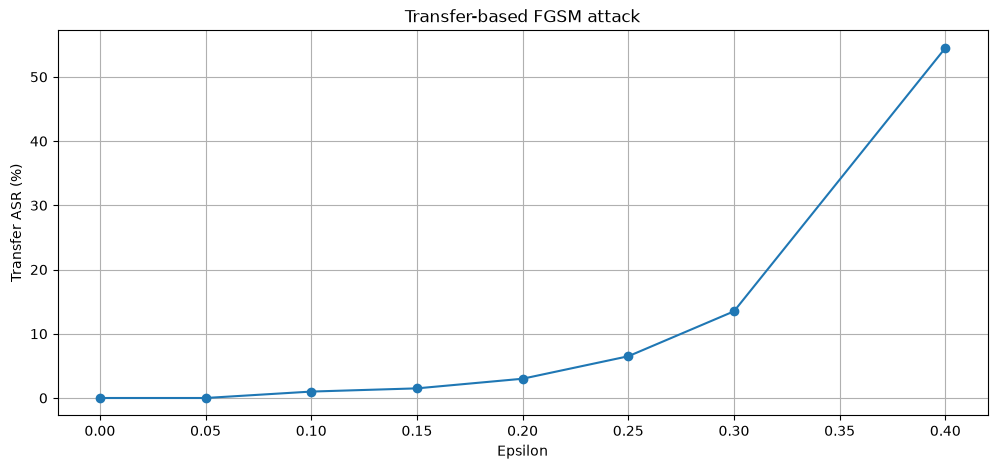

In [34]:
oracle.reset()

epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]
transfer_asr = []

# Берём 200 тестовых изображений
test_images, test_labels = next(iter(test_loader))

test_images = test_images[:200].to(device)
test_labels = test_labels[:200].to(device)

for epsilon in epsilons:
    # FGSM строим на суррогатной модели
    adv_images = fgsm_attack(
        substitute_model,
        test_images,
        test_labels,
        epsilon=epsilon,
        criterion=crit_sub
    )

    # Предсказания исходных изображений через оракул
    original_labels = oracle.label(test_images)

    # Предсказания adversarial изображений через оракул
    adversarial_labels = oracle.label(adv_images)

    # Transfer ASR: доля изменившихся предсказаний
    changed = (original_labels != adversarial_labels).sum().item()
    asr = 100 * changed / len(test_images)

    transfer_asr.append(asr)

plt.figure(figsize=(12, 5))

plt.plot(
    epsilons,
    transfer_asr,
    marker="o"
)

plt.xlabel("Epsilon")
plt.ylabel("Transfer ASR (%)")
plt.title("Transfer-based FGSM attack")
plt.grid(True)
plt.show()

In [35]:
for epsilon in epsilons:
    adv_images = fgsm_attack(
        substitute_model,
        test_images,
        test_labels,
        epsilon=epsilon,
        criterion=crit_sub
    )

    with torch.no_grad():
        clean_pred = substitute_model(test_images).argmax(dim=1)
        adv_pred = substitute_model(adv_images).argmax(dim=1)

    asr = (clean_pred != adv_pred).float().mean().item() * 100

    print(f"epsilon={epsilon:.2f} | Substitute ASR={asr:.2f}%")

epsilon=0.00 | Substitute ASR=0.00%
epsilon=0.05 | Substitute ASR=39.00%
epsilon=0.10 | Substitute ASR=51.50%
epsilon=0.15 | Substitute ASR=65.50%
epsilon=0.20 | Substitute ASR=72.50%
epsilon=0.25 | Substitute ASR=79.50%
epsilon=0.30 | Substitute ASR=82.50%
epsilon=0.40 | Substitute ASR=87.00%


Переносимоть атаки небольшая. Для epsilon=0.3 всего 13%

### 2.3. Сравнение с белоящичным эталоном

**Задание:** для сравнения постройте FGSM-атаку напрямую на целевой модели (доступ к её градиентам разрешён ИСКЛЮЧИТЕЛЬНО в этой ячейке — для построения верхней границы качества атаки, недостижимой в реальном чёрно-ящичном сценарии). Постройте оба графика ASR(epsilon) на одной оси.

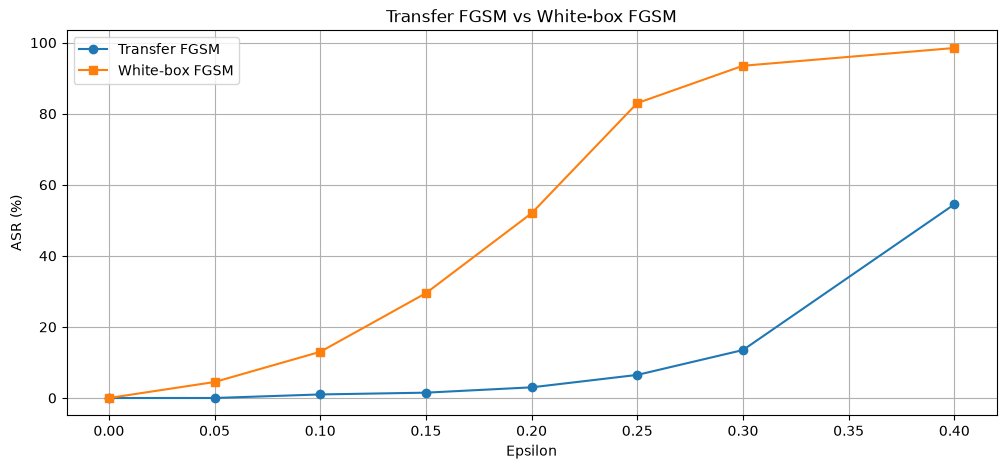

In [36]:
oracle.reset()

whitebox_asr = []

for epsilon in epsilons:
    # FGSM напрямую на target_model — white-box эталон
    adv_images = fgsm_attack(
        target_model,
        test_images,
        test_labels,
        epsilon=epsilon,
        criterion=crit
    )

    # Предсказания target на исходных изображениях
    clean_labels = oracle.label(test_images)

    # Предсказания target на adversarial изображениях
    adv_labels = oracle.label(adv_images)

    # Доля изменившихся предсказаний
    changed = (clean_labels != adv_labels).sum().item()
    asr = 100 * changed / len(test_images)

    whitebox_asr.append(asr)

plt.figure(figsize=(12, 5))

plt.plot(
    epsilons,
    transfer_asr,
    marker="o",
    label="Transfer FGSM"
)

plt.plot(
    epsilons,
    whitebox_asr,
    marker="s",
    label="White-box FGSM"
)

plt.xlabel("Epsilon")
plt.ylabel("ASR (%)")
plt.title("Transfer FGSM vs White-box FGSM")
plt.grid(True)
plt.legend()
plt.show()

**Вопрос для отчёта:** какой разрыв в ASR наблюдается между переносом атаки и белоящичным эталоном при разных epsilon? Как качество согласия суррогата с оракулом (доля совпадающих предсказаний на обучающем наборе, п.2.1) связано с этим разрывом?

_Ваш ответ:_ 

## Часть III. Score-based атаки

### 3.1. ZOO: оценка градиента через конечные разности

**Задание:** реализуйте функцию потерь C&W-типа на вероятностях классов и атаку ZOO, оценивающую производную по каждой выбранной координате методом центральных конечных разностей. Атака должна использовать ТОЛЬКО `oracle.probs(x)` — доступ к градиентам запрещён.

$$f(x) = \max\left(\log p_{true}(x) -\max_{i \ne true}\log p_i(x),-\kappa\right)$$

In [37]:
def zoo_loss(probs, y_true, kappa=0.0):
    batch_idx = torch.arange(probs.size(0), device=probs.device)

    true_prob = probs[batch_idx, y_true]

    other_probs = probs.clone()
    other_probs[batch_idx, y_true] = 0.0

    max_other_prob = other_probs.max(dim=1).values

    true_log_prob = torch.log(true_prob + 1e-12)
    max_other_log_prob = torch.log(max_other_prob + 1e-12)

    f = true_log_prob - max_other_log_prob

    return torch.clamp(f, min=-kappa)

$$\frac{\partial f}{\partial x_i}\approx\frac{f(x + h e_i) - f(x - h e_i)}{2h}$$

In [38]:
def zoo_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, h=0.05, coord_batch=40):
    x_adv = x.clone().detach()

    batch_size = x.size(0)
    num_coords = x[0].numel()

    for _ in range(num_iter):
        flat_x = x_adv.reshape(batch_size, -1)
        flat_grad = torch.zeros_like(flat_x)

        coords = torch.randperm(num_coords, device=x.device)[:coord_batch] # Выбираем случайные пиксели

        # Оцениваем производную и считаем приближенный градиент
        for coord in coords:
            x_plus = x_adv.clone()
            x_minus = x_adv.clone()

            x_plus.reshape(batch_size, -1)[:, coord] += h
            x_minus.reshape(batch_size, -1)[:, coord] -= h

            x_plus = torch.clamp(x_plus, 0, 1)
            x_minus = torch.clamp(x_minus, 0, 1)

            probs_plus = oracle.probs(x_plus)
            probs_minus = oracle.probs(x_minus)

            loss_plus = zoo_loss(
                probs_plus,
                y_true
            )

            loss_minus = zoo_loss(
                probs_minus,
                y_true
            )

            derivative = (loss_plus - loss_minus) / (2 * h)

            flat_grad[:, coord] = derivative

        # Сдвигаем изображение (минимизируем zoo_loss)
        x_adv = x_adv - alpha * flat_grad.sign().reshape_as(x_adv)

        # Ограничиваем по норме Linf
        delta = x_adv - x
        delta = torch.clamp(
            delta,
            -epsilon,
            epsilon
        )

        x_adv = torch.clamp(
            x + delta,
            0,
            1
        ).detach()

    return x_adv

### 3.2. Демонстрация ZOO-атаки

**Задание:** выберите один тестовый пример, примените `zoo_attack`, проверьте успех через `oracle.label`, посчитайте L2-норму возмущения и число потраченных запросов. Визуализируйте оригинал и adversarial-пример.

In [39]:
# Смотрим для каждого epsilon приближенное число запросов
epsilons = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4]
values = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]

results = []

x_sample, y_sample_label = test_dataset[0]

x_sample = x_sample.unsqueeze(0).to(device)
y_sample = torch.tensor([y_sample_label], device=device)

original_label = oracle.label(x_sample).item()

for epsilon in epsilons:
    found = False

    for value in values:
        num_iter = value
        coord_batch = value

        oracle.reset()

        x_adv = zoo_attack(
            oracle,
            x_sample,
            y_sample,
            epsilon=epsilon,
            alpha=0.1,
            num_iter=num_iter,
            h=0.05,
            coord_batch=coord_batch
        )

        adv_label = oracle.label(x_adv).item()
        success = adv_label != original_label

        if success:
            perturbation = x_adv - x_sample
            l2 = torch.norm(
                perturbation.reshape(-1),
                p=2
            ).item()

            results.append({
                "epsilon": epsilon,
                "min_num_iter": num_iter,
                "min_coord_batch": coord_batch,
                "l2": l2,
                "queries": oracle.n_queries,
                "adv_label": adv_label
            })

            found = True
            break

    if not found:
        results.append({
            "epsilon": epsilon,
            "min_num_iter": None,
            "min_coord_batch": None,
            "l2": None,
            "queries": None,
            "adv_label": None
        })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

 epsilon  min_num_iter  min_coord_batch       l2  queries  adv_label
    0.10           NaN              NaN      NaN      NaN        NaN
    0.15           NaN              NaN      NaN      NaN        NaN
    0.20          55.0             55.0 3.508257   6051.0        9.0
    0.25          45.0             45.0 3.661940   4051.0        9.0
    0.30          40.0             40.0 3.833580   3201.0        9.0
    0.40          40.0             40.0 3.935705   3201.0        9.0


ZOO позволяет провести атаку при epsilon = 0.2, но для сравнения с NES возьмем 0.3

In [40]:
import time
oracle.reset()

# Берём один пример из тестовой выборки
x_sample, y_sample_label = test_dataset[0]

x_sample = x_sample.unsqueeze(0).to(device)
y_sample = torch.tensor([y_sample_label], device=device)

# Предсказание исходного изображения
original_label = oracle.label(x_sample).item()

# Запускаем ZOO-атаку
start_time = time.time()

x_adv = zoo_attack(
    oracle,
    x_sample,
    y_sample,
    epsilon=0.3,
    alpha=0.2,
    num_iter=35,
    h=0.05,
    coord_batch=30
)

elapsed_time = time.time() - start_time

# Предсказание adversarial-примера
adv_label = oracle.label(x_adv).item()

# Проверяем успех атаки
success = adv_label != original_label

# L2-норма возмущения
perturbation = x_adv - x_sample
l2_norm = torch.norm(
    perturbation.reshape(-1),
    p=2
).item()

# Количество запросов к oracle
n_queries = oracle.n_queries

zoo_result = {
    "attack": "ZOO",
    "epsilon": 0.3,
    "success": success,
    "l2": l2_norm,
    "queries": n_queries,
    "time": elapsed_time
}

print(f"Исходный класс: {original_label}")
print(f"Класс после атаки: {adv_label}")
print(f"Успех атаки: {success}")
print(f"L2-норма: {l2_norm:.4f}")
print(f"Запросов к oracle: {n_queries}")
print(f"Время выполнения: {elapsed_time:.2f} сек.")

Исходный класс: 7
Класс после атаки: 9
Успех атаки: True
L2-норма: 4.1561
Запросов к oracle: 2102
Время выполнения: 1.14 сек.


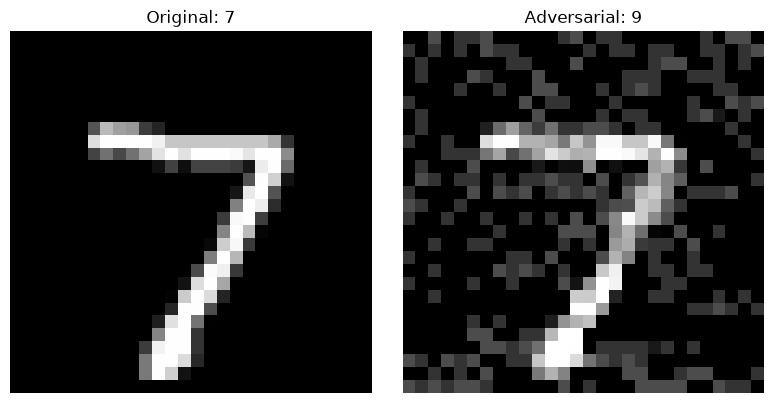

In [41]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    x_sample[0].detach().cpu().squeeze(),
    cmap="gray"
)
plt.title(f"Original: {original_label}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    x_adv[0].detach().cpu().squeeze(),
    cmap="gray"
)
plt.title(f"Adversarial: {adv_label}")
plt.axis("off")

plt.tight_layout()
plt.show()

### 3.3. NES: оценка градиента через антитетическую случайную выборку

**Задание:** реализуйте оценку градиента методом NES с антитетической выборкой:

$ \hat{g} = \frac{1}{2\sigma P} \sum_{i=1}^{P} \left( L(x + \sigma u_i) - L(x - \sigma u_i) \right) u_i $

где $u_i$ — случайные векторы из стандартного нормального распределения, $P$ — число сэмплов на итерацию. Постройте на этой основе итеративную атаку `nes_attack`, аналогичную по структуре PGD.

In [43]:
def nes_gradient_estimate(oracle, x, y_true, sigma=0.1, n_samples=20):
    grad = torch.zeros_like(x)

    for _ in range(n_samples):
        u = torch.randn_like(x)

        x_plus = torch.clamp(x + sigma * u, 0, 1)
        x_minus = torch.clamp(x - sigma * u, 0, 1)

        probs_plus = oracle.probs(x_plus)
        probs_minus = oracle.probs(x_minus)

        loss_plus = zoo_loss(probs_plus, y_true)
        loss_minus = zoo_loss(probs_minus, y_true)

        grad += (
            (loss_plus - loss_minus)
            .view(-1, 1, 1, 1) * u
        )

    grad /= (2 * sigma * n_samples)

    return grad

In [44]:
def nes_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, sigma=0.1, n_samples=20):
    x_adv = x.clone().detach()

    for _ in range(num_iter):

        grad = nes_gradient_estimate(
            oracle,
            x_adv,
            y_true,
            sigma=sigma,
            n_samples=n_samples
        )

        x_adv = x_adv - alpha * grad.sign()

        delta = x_adv - x
        delta = torch.clamp(
            delta,
            -epsilon,
            epsilon
        )

        x_adv = torch.clamp(
            x + delta,
            0,
            1
        ).detach()

    return x_adv

In [46]:
oracle.reset()

x_sample, y_sample_label = test_dataset[0]

x_sample = x_sample.unsqueeze(0).to(device)
y_sample = torch.tensor(
    [y_sample_label],
    device=device
)

original_label = oracle.label(x_sample).item()

start_time = time.time()

x_adv = nes_attack(
    oracle,
    x_sample,
    y_sample,
    epsilon=0.3,
    alpha=0.05,
    num_iter=30,
    sigma=0.1,
    n_samples=25
)

elapsed_time = time.time() - start_time

adv_label = oracle.label(x_adv).item()

success = adv_label != original_label

perturbation = x_adv - x_sample

l2_norm = torch.norm(
    perturbation.reshape(-1),
    p=2
).item()

nes_result = {
    "attack": "NES",
    "epsilon": 0.3,
    "success": success,
    "l2": l2_norm,
    "queries": oracle.n_queries,
    "time": elapsed_time
}

print(f"Исходный класс: {original_label}")
print(f"Класс после атаки: {adv_label}")
print(f"Успех атаки: {success}")
print(f"L2-норма: {l2_norm:.4f}")
print(f"Запросов к oracle: {oracle.n_queries}")
print(f"Время выполнения: {elapsed_time:.2f} сек.")

Исходный класс: 7
Класс после атаки: 9
Успех атаки: True
L2-норма: 5.0882
Запросов к oracle: 1502
Время выполнения: 1.13 сек.


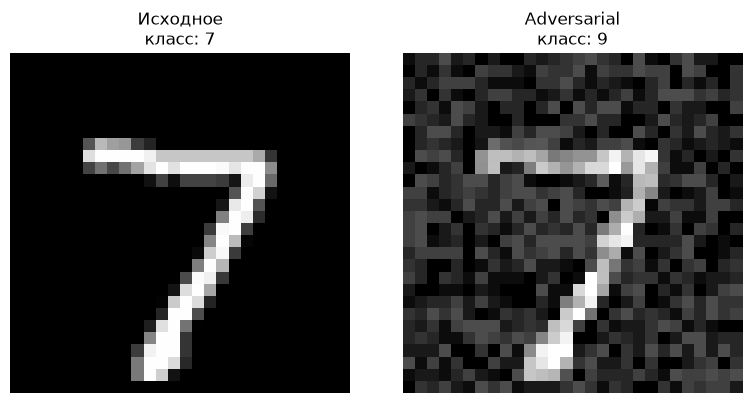

In [47]:
x_original = x_sample.squeeze().detach().cpu().numpy()
x_adversarial = x_adv.squeeze().detach().cpu().numpy()

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(x_original, cmap="gray")
plt.title(f"Исходное\nкласс: {original_label}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(x_adversarial, cmap="gray")
plt.title(f"Adversarial\nкласс: {adv_label}")
plt.axis("off")

plt.tight_layout()
plt.show()

### 3.4. Сравнение ZOO и NES

**Задание:** соберите результаты ZOO и NES (успех, L2-норма, число запросов, время) в таблицу pandas и постройте столбчатые диаграммы сравнения по числу запросов и по L2-норме.

In [48]:
comparison_df = pd.DataFrame([
    zoo_result,
    nes_result
])
comparison_df

,attack,epsilon,success,l2,queries,time
0,ZOO,0.3,True,4.156089,2102,1.144412
1,NES,0.3,True,5.088209,1502,1.131241


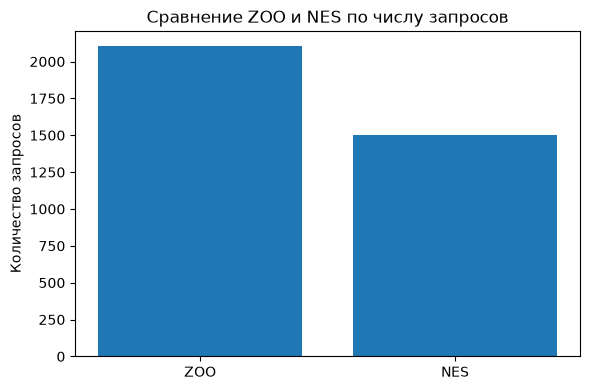

In [49]:
plt.figure(figsize=(6, 4))

plt.bar(
    comparison_df["attack"],
    comparison_df["queries"]
)

plt.ylabel("Количество запросов")
plt.title("Сравнение ZOO и NES по числу запросов")

plt.tight_layout()
plt.show()

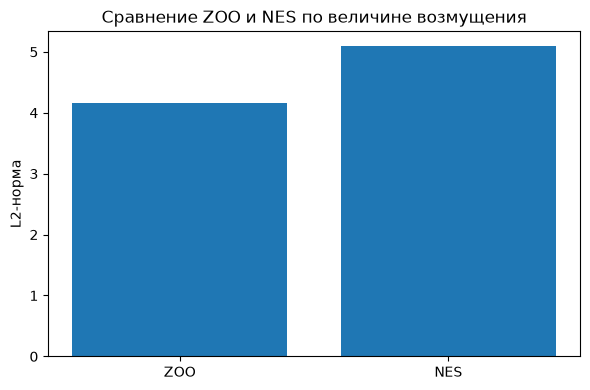

In [50]:
plt.figure(figsize=(6, 4))

plt.bar(
    comparison_df["attack"],
    comparison_df["l2"]
)

plt.ylabel("L2-норма")
plt.title("Сравнение ZOO и NES по величине возмущения")

plt.tight_layout()
plt.show()

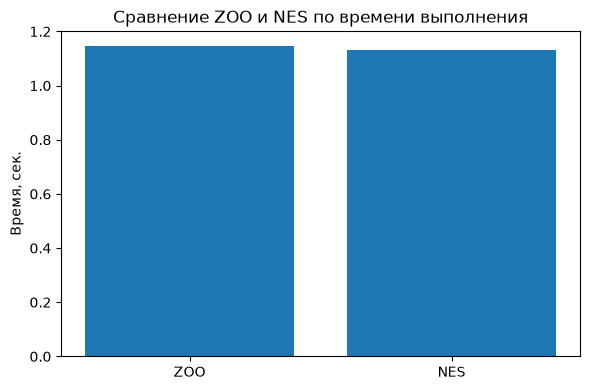

In [51]:
plt.figure(figsize=(6, 4))

plt.bar(
    comparison_df["attack"],
    comparison_df["time"]
)

plt.ylabel("Время, сек.")
plt.title("Сравнение ZOO и NES по времени выполнения")

plt.tight_layout()
plt.show()

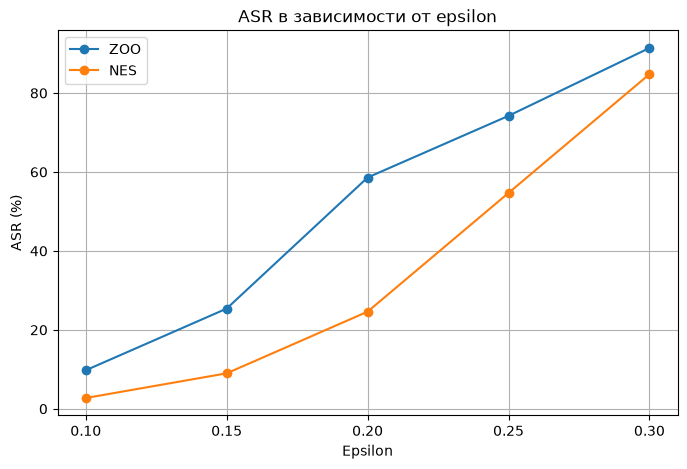

In [52]:
epsilons = [0.1, 0.15, 0.2, 0.25, 0.3]

zoo_asr = []
nes_asr = []

for eps in epsilons:
    zoo_success = 0
    nes_success = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            original_preds = oracle.model(images).argmax(dim=1)

        # ZOO
        zoo_adv = zoo_attack(
            oracle,
            images,
            labels,
            epsilon=eps,
            alpha=0.2,
            num_iter=35,
            h=0.05,
            coord_batch=30
        )

        # NES
        nes_adv = nes_attack(
            oracle,
            images,
            labels,
            epsilon=eps,
            alpha=0.05,
            num_iter=35,
            sigma=0.1,
            n_samples=30
        )

        with torch.no_grad():
            zoo_preds = oracle.model(zoo_adv).argmax(dim=1)
            nes_preds = oracle.model(nes_adv).argmax(dim=1)

        zoo_success += (original_preds != zoo_preds).sum().item()
        nes_success += (original_preds != nes_preds).sum().item()
        total += labels.size(0)

        if total >= 200:
            break

    zoo_asr.append(100 * zoo_success / total)
    nes_asr.append(100 * nes_success / total)

asr_df = pd.DataFrame({
    "epsilon": epsilons,
    "ZOO ASR": zoo_asr,
    "NES ASR": nes_asr
})

plt.figure(figsize=(8, 5))

plt.plot(epsilons, zoo_asr, marker="o", label="ZOO")
plt.plot(epsilons, nes_asr, marker="o", label="NES")

plt.xlabel("Epsilon")
plt.ylabel("ASR (%)")
plt.title("ASR в зависимости от epsilon")
plt.xticks(epsilons)
plt.grid(True)
plt.legend()
plt.show()

**Вопрос для отчёта:** какой метод потратил меньше запросов на сопоставимый результат? Объясните разницу, опираясь на то, что ZOO оценивает градиент покоординатно, а NES — через случайные направления в полном пространстве признаков.

_Ваш ответ:_ Для сопоставимого результата NES требуется меньшее  количество запросов (на 30%). Но при этом у NES ниже ASR для одного и того же epsilon, а также выше зашумленность изображения (L2)

## Часть IV. Decision-based атака: Boundary Attack

### 4.1. Реализация упрощённой Boundary Attack

**Задание:** реализуйте функцию `is_adversarial`, которая через `oracle.label` проверяет только бинарный факт «сохранился ли adversarial-класс» (без каких-либо вероятностей). На основе неё реализуйте `boundary_attack`:

1. Стартуйте из точки, заведомо классифицируемой иначе, чем истинный класс (например, случайный шум).
2. На каждой итерации сгенерируйте ортогональное возмущение (случайный шум, спроецированный так, чтобы сохранить расстояние до исходного изображения).
3. Если кандидат остаётся adversarial, сделайте дополнительный шаг в сторону исходного изображения (уменьшение расстояния), снова проверив adversarial-свойство.
4. Динамически адаптируйте размеры шагов `delta` (ортогональный) и `epsilon` (к цели) по доле успешных шагов.

In [53]:
def is_adversarial(oracle, x, true_label):
    return oracle.label(x).item() != true_label.item()

In [ ]:
def boundary_attack(oracle, x_orig, true_label, x_init, num_steps=500, init_delta=0.05, init_epsilon=0.05):
    x_adv = x_init.clone().detach()

    delta = init_delta
    epsilon = init_epsilon

    history = []

    for _ in range(num_steps):
        diff = x_adv - x_orig
        diff_norm = torch.norm(diff.reshape(-1), p=2) # Считаем L2 норму

        # Случайный шум
        noise = torch.randn_like(x_adv)

        # Делаем шум ортогональным diff (убираем составляющую вдоль diff)
        diff_flat = diff.reshape(-1)
        noise_flat = noise.reshape(-1)

        projection = (
            torch.dot(noise_flat, diff_flat)
            / (torch.dot(diff_flat, diff_flat) + 1e-12)
        ) * diff_flat

        orthogonal_noise = noise_flat - projection
        orthogonal_noise = orthogonal_noise.reshape_as(x_adv)

        # Считаем L2 норму
        noise_norm = torch.norm(
            orthogonal_noise.reshape(-1),
            p=2
        )

        # Нормализуем (теперь это единичный вектор)
        orthogonal_noise = (
            orthogonal_noise / (noise_norm + 1e-12)
        )

        # Ортогональный шаг (вдоль границы)
        x_candidate = (
            x_adv
            + delta * diff_norm * orthogonal_noise
        )

        x_candidate = torch.clamp(x_candidate, 0, 1)

        if is_adversarial(
            oracle,
            x_candidate,
            true_label
        ):
            # Шаг к исходному изображению
            x_towards = (
                x_candidate
                + epsilon * (x_orig - x_candidate)
            )

            x_towards = torch.clamp(
                x_towards,
                0,
                1
            )

            if is_adversarial(
                oracle,
                x_towards,
                true_label
            ):
                x_adv = x_towards # Новый adversarial, если удались оба шага

                delta *= 1.02
                epsilon *= 1.02
            else:
                x_adv = x_candidate # Если только шаг в сторону
                delta *= 0.98

        else: # Если не удался ни один шаг
            delta *= 0.98
            epsilon *= 0.98

        current_l2 = torch.norm(
            (x_adv - x_orig).reshape(-1),
            p=2
        ).item()

        history.append(current_l2)

    return x_adv.detach(), history

### 4.2. Демонстрация атаки

**Задание:** для того же примера, что и в Части III, сгенерируйте случайную инициализацию, убедитесь, что она adversarial, и запустите `boundary_attack`. Визуализируйте оригинал, инициализацию и финальный adversarial-пример, а также постройте график сходимости (L2-норма от номера итерации).

In [55]:
oracle.reset()

x_orig, true_label_value = test_dataset[0]

x_orig = x_orig.unsqueeze(0).to(device)
true_label = torch.tensor(
    [true_label_value],
    device=device
)

# Ищем adversarial инициализацию
while True:
    x_init = torch.rand_like(x_orig)

    if is_adversarial(oracle, x_init, true_label):
        break

print(f"Истинный класс: {true_label.item()}")
print(f"Класс x_init: {oracle.label(x_init).item()}")

start_time = time.time()

x_adv, history = boundary_attack(
    oracle,
    x_orig,
    true_label,
    x_init,
    num_steps=50,
    init_delta=0.05,
    init_epsilon=0.05
)

elapsed_time = time.time() - start_time

final_label = oracle.label(x_adv).item()

l2_norm = torch.norm(
    (x_adv - x_orig).reshape(-1),
    p=2
).item()

success = final_label != true_label.item()

print(f"\nФинальный класс: {final_label}")
print(f"Успех атаки: {success}")
print(f"L2-норма: {l2_norm:.4f}")
print(f"Запросов к oracle: {oracle.n_queries}")
print(f"Время выполнения: {elapsed_time:.2f} сек.")

Истинный класс: 7
Класс x_init: 8

Финальный класс: 3
Успех атаки: True
L2-норма: 10.5315
Запросов к oracle: 99
Время выполнения: 0.06 сек.


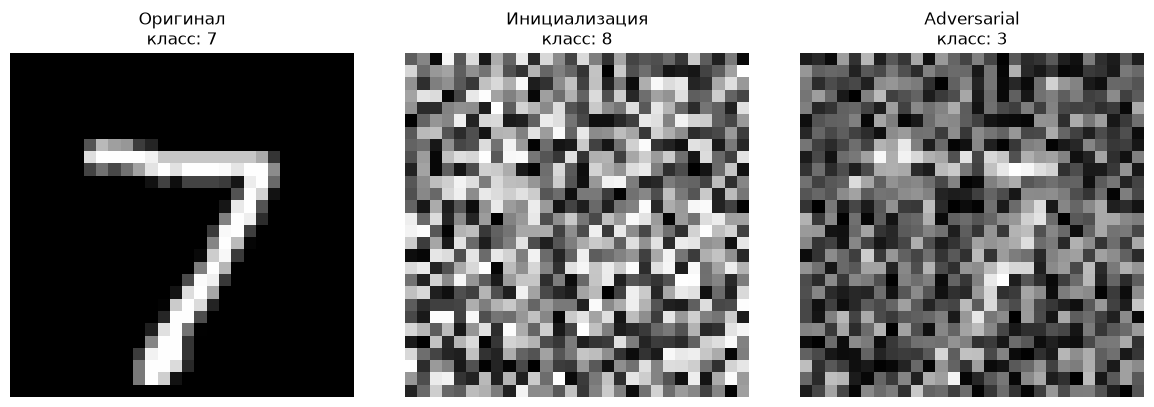

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(
    x_orig.squeeze().detach().cpu().numpy(),
    cmap="gray"
)
axes[0].set_title(f"Оригинал\nкласс: {true_label.item()}")
axes[0].axis("off")

axes[1].imshow(
    x_init.squeeze().detach().cpu().numpy(),
    cmap="gray"
)
axes[1].set_title(
    f"Инициализация\nкласс: {oracle.label(x_init).item()}"
)
axes[1].axis("off")

axes[2].imshow(
    x_adv.squeeze().detach().cpu().numpy(),
    cmap="gray"
)
axes[2].set_title(f"Adversarial\nкласс: {final_label}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [69]:
oracle.reset()

# Исходное изображение 7
x_orig, true_label_value = test_dataset[0]

x_orig = x_orig.unsqueeze(0).to(device)

true_label = torch.tensor(
    [true_label_value],
    device=device
)

# Берём реальное изображение цифры 2
for i in range(len(test_dataset)):
    image, label = test_dataset[i]

    if label == 2:
        x_init = image.unsqueeze(0).to(device)
        break

print(f"Истинный класс: {true_label.item()}")
print(f"Класс x_init: {oracle.label(x_init).item()}")

start_time = time.time()

x_adv, history = boundary_attack(
    oracle,
    x_orig,
    true_label,
    x_init,
    num_steps=50,
    init_delta=0.05,
    init_epsilon=0.05
)

elapsed_time = time.time() - start_time

final_label = oracle.label(x_adv).item()

l2_norm = torch.norm(
    (x_adv - x_orig).reshape(-1),
    p=2
).item()

success = final_label != true_label.item()

print(f"\nФинальный класс: {final_label}")
print(f"Успех атаки: {success}")
print(f"L2-норма: {l2_norm:.4f}")
print(f"Запросов к oracle: {oracle.n_queries}")
print(f"Время выполнения: {elapsed_time:.2f} сек.")

Истинный класс: 7
Класс x_init: 2

Финальный класс: 2
Успех атаки: True
L2-норма: 4.5786
Запросов к oracle: 102
Время выполнения: 0.05 сек.


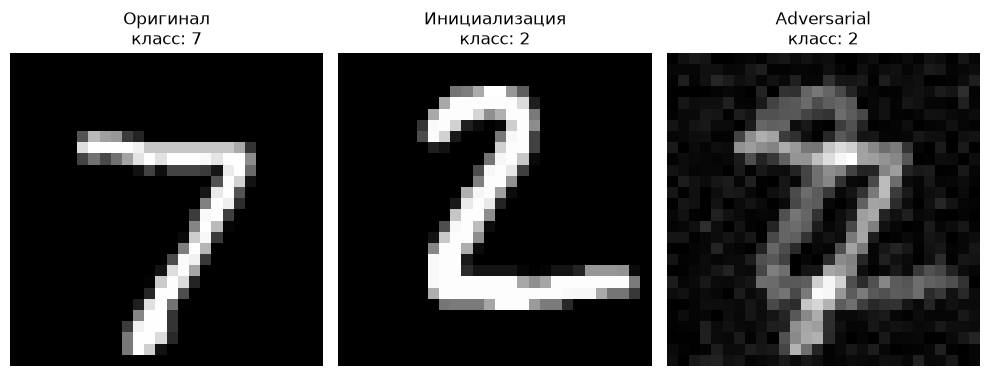

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].imshow(
    x_orig.squeeze().detach().cpu().numpy(),
    cmap="gray"
)
axes[0].set_title(f"Оригинал\nкласс: {true_label.item()}")
axes[0].axis("off")

axes[1].imshow(
    x_init.squeeze().detach().cpu().numpy(),
    cmap="gray"
)
axes[1].set_title(
    f"Инициализация\nкласс: {oracle.label(x_init).item()}"
)
axes[1].axis("off")

axes[2].imshow(
    x_adv.squeeze().detach().cpu().numpy(),
    cmap="gray"
)
axes[2].set_title(
    f"Adversarial\nкласс: {final_label}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** почему decision-based атака в принципе не может напрямую оценивать градиент функции потерь, в отличие от score-based методов? Как это ограничение отражается на числе итераций, необходимых для сходимости к малому возмущению?

_Ваш ответ:_ 

## Часть V. Итоговое сравнение четырёх методов

**Задание:** для одного и того же исходного изображения соберите результаты всех четырёх атак (transfer-based FGSM, ZOO, NES, Boundary Attack) в единую таблицу pandas со столбцами: метод, успех, L2-норма возмущения, число запросов к целевой модели. Сохраните таблицу в CSV. Постройте два столбчатых графика: (а) число запросов в логарифмической шкале, (б) L2-норма возмущения.

Исходный класс: 7

=== Transfer-based FGSM ===
Исходный класс: 7
Adversarial класс: 7
Успех: False
L2: 6.6528
Запросов: 2
Время: 0.00 сек.

=== ZOO ===
Adversarial класс: 9
Успех: True
L2: 3.9399
Запросов: 2101
Время: 0.94 сек.

=== NES ===
Adversarial класс: 9
Успех: True
L2: 5.1970
Запросов: 2001
Время: 0.94 сек.

=== Boundary Attack ===
Начальный класс: 3
Финальный класс: 3
Успех: True
L2: 5.3841
Запросов: 101
Время: 0.04 сек.


,метод,успех,L2-норма,запросы
0,Transfer-based FGSM,False,6.652820,2
1,ZOO,True,3.939908,2101
2,NES,True,5.196986,2001
3,Boundary Attack,True,5.384082,101



Сохранено: lab6_summary.csv


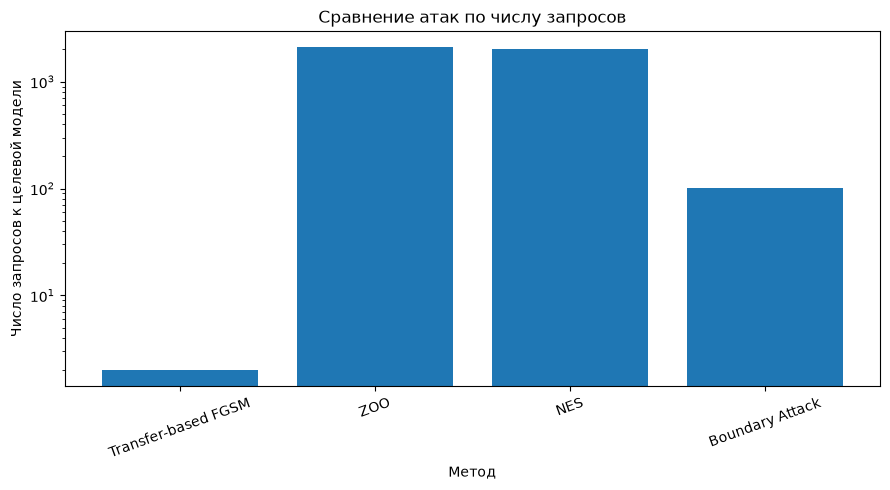

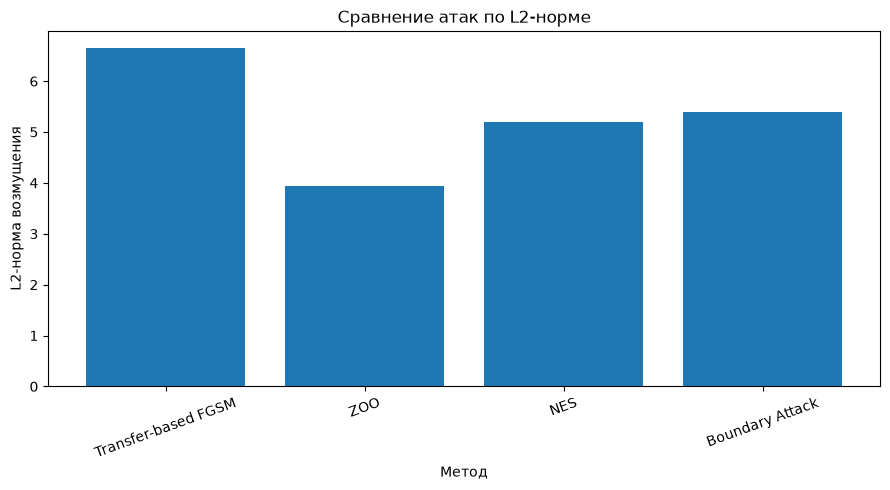

In [71]:
# ============================================================
# Одно исходное изображение
# ============================================================

x_orig, true_label_value = test_dataset[0]

x_orig = x_orig.unsqueeze(0).to(device)

true_label = torch.tensor(
    [true_label_value],
    device=device
)

print(f"Исходный класс: {true_label.item()}")


# ============================================================
# 1. Transfer-based FGSM
# ============================================================

print("\n=== Transfer-based FGSM ===")

substitute_model.eval()

epsilon_fgsm = 0.3

start_time = time.time()

x_adv_fgsm = fgsm_attack(
    substitute_model,
    x_orig,
    true_label,
    epsilon=epsilon_fgsm,
    criterion=crit
)

fgsm_time = time.time() - start_time

# Единственный запрос к целевой модели
oracle.reset()

original_target_label = oracle.label(x_orig).item()
adv_target_label = oracle.label(x_adv_fgsm).item()

fgsm_success = adv_target_label != original_target_label

fgsm_l2 = torch.norm(
    (x_adv_fgsm - x_orig).reshape(-1),
    p=2
).item()

fgsm_queries = oracle.n_queries

print(f"Исходный класс: {original_target_label}")
print(f"Adversarial класс: {adv_target_label}")
print(f"Успех: {fgsm_success}")
print(f"L2: {fgsm_l2:.4f}")
print(f"Запросов: {fgsm_queries}")
print(f"Время: {fgsm_time:.2f} сек.")


# ============================================================
# 2. ZOO
# ============================================================

print("\n=== ZOO ===")

oracle.reset()

start_time = time.time()

x_adv_zoo = zoo_attack(
    oracle,
    x_orig,
    true_label,
    epsilon=0.3,
    alpha=0.2,
    num_iter=35,
    h=0.05,
    coord_batch=30
)

zoo_time = time.time() - start_time

zoo_label = oracle.label(x_adv_zoo).item()

zoo_success = zoo_label != true_label.item()

zoo_l2 = torch.norm(
    (x_adv_zoo - x_orig).reshape(-1),
    p=2
).item()

zoo_queries = oracle.n_queries

print(f"Adversarial класс: {zoo_label}")
print(f"Успех: {zoo_success}")
print(f"L2: {zoo_l2:.4f}")
print(f"Запросов: {zoo_queries}")
print(f"Время: {zoo_time:.2f} сек.")


# ============================================================
# 3. NES
# ============================================================

print("\n=== NES ===")

oracle.reset()

start_time = time.time()

x_adv_nes = nes_attack(
    oracle,
    x_orig,
    true_label,
    epsilon=0.3,
    alpha=0.05,
    num_iter=40,
    sigma=0.1,
    n_samples=25
)

nes_time = time.time() - start_time

nes_label = oracle.label(x_adv_nes).item()

nes_success = nes_label != true_label.item()

nes_l2 = torch.norm(
    (x_adv_nes - x_orig).reshape(-1),
    p=2
).item()

nes_queries = oracle.n_queries

print(f"Adversarial класс: {nes_label}")
print(f"Успех: {nes_success}")
print(f"L2: {nes_l2:.4f}")
print(f"Запросов: {nes_queries}")
print(f"Время: {nes_time:.2f} сек.")


# ============================================================
# 4. Boundary Attack
# ============================================================

print("\n=== Boundary Attack ===")

# Находим настоящее изображение цифры 3,
# которое целевая модель действительно классифицирует как 3.

x_init = None

for i in range(len(test_dataset)):
    image, label = test_dataset[i]

    if label == 3:
        candidate = image.unsqueeze(0).to(device)

        if oracle.label(candidate).item() == 3:
            x_init = candidate
            break

if x_init is None:
    raise RuntimeError("Не удалось найти изображение 3, которое модель классифицирует как 3.")

oracle.reset()

start_time = time.time()

x_adv_boundary, boundary_history = boundary_attack(
    oracle,
    x_orig,
    true_label,
    x_init,
    num_steps=50,
    init_delta=0.05,
    init_epsilon=0.05
)

boundary_time = time.time() - start_time

boundary_label = oracle.label(x_adv_boundary).item()

boundary_success = boundary_label != true_label.item()

boundary_l2 = torch.norm(
    (x_adv_boundary - x_orig).reshape(-1),
    p=2
).item()

boundary_queries = oracle.n_queries

print(f"Начальный класс: {oracle.label(x_init).item()}")
print(f"Финальный класс: {boundary_label}")
print(f"Успех: {boundary_success}")
print(f"L2: {boundary_l2:.4f}")
print(f"Запросов: {boundary_queries}")
print(f"Время: {boundary_time:.2f} сек.")


# ============================================================
# Итоговая таблица
# ============================================================

summary = pd.DataFrame([
    {
        "метод": "Transfer-based FGSM",
        "успех": fgsm_success,
        "L2-норма": fgsm_l2,
        "запросы": fgsm_queries
    },
    {
        "метод": "ZOO",
        "успех": zoo_success,
        "L2-норма": zoo_l2,
        "запросы": zoo_queries
    },
    {
        "метод": "NES",
        "успех": nes_success,
        "L2-норма": nes_l2,
        "запросы": nes_queries
    },
    {
        "метод": "Boundary Attack",
        "успех": boundary_success,
        "L2-норма": boundary_l2,
        "запросы": boundary_queries
    }
])

display(summary)


# ============================================================
# Сохранение
# ============================================================

summary.to_csv(
    "lab6_summary.csv",
    index=False
)

print("\nСохранено: lab6_summary.csv")


# ============================================================
# График 1: число запросов
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    summary["метод"],
    summary["запросы"]
)

plt.yscale("log")

plt.xlabel("Метод")
plt.ylabel("Число запросов к целевой модели")
plt.title("Сравнение атак по числу запросов")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


# ============================================================
# График 2: L2-норма
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    summary["метод"],
    summary["L2-норма"]
)

plt.xlabel("Метод")
plt.ylabel("L2-норма возмущения")
plt.title("Сравнение атак по L2-норме")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** на основе итоговой таблицы сформулируйте рекомендацию: какой метод атаки предпочтителен, если API целевой модели предоставляет (а) полные вероятности классов без ограничения на число запросов, (б) только top-1 метку с жёстким лимитом запросов, (в) возможность собрать offline небольшой размеченный набор данных того же домена? Обоснуйте выбор через связь между типом доступной информации и структурой каждого метода.

_Ваш ответ:_ а) ZOO б) Boundary Attack в) FGSM

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх классах чёрно-ящичных атак, изученных в работе. Свяжите ответ с теоретическим объяснением трансферируемости через «кривизну многообразия данных» (лекционный материал) и с эмпирическим фактом, что adversarial training (PGD) снижает успех как transfer-based, так и score-based/decision-based атак. Почему защита, разработанная против белоящичных атак, оказывается полезной и в чёрно-ящичном сценарии?

_Ваш ответ:_ 

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Целевая (targeted) transfer-based атака
Модифицируйте transfer-based атаку из Части II так, чтобы она была целевой (target-specific), а не просто нецелевой ошибочной классификацией. Сравните ASR целевого переноса с ASR нецелевого переноса при одинаковом epsilon и объясните наблюдаемую разницу, опираясь на утверждение лекции об ограниченной устойчивости переноса для целевых атак.

### С2. Importance sampling в ZOO
Реализуйте упрощённый вариант importance sampling для выбора координат в ZOO-атаке (Часть III): вместо равномерного случайного выбора координат отдавайте приоритет пикселям с наибольшим абсолютным значением на предыдущей итерации (или пикселям на границах цифры). Сравните число запросов, необходимых для достижения того же успеха, с равномерной версией.

### С3. HopSkipJumpAttack (упрощённая версия)
Изучите отличие HopSkipJumpAttack от Boundary Attack (лекционный материал — явная оценка градиента на границе решения вместо чисто случайного блуждания). Реализуйте упрощённую версию: на каждой итерации находите точку на границе бинарным поиском, оцените направление через батч случайных векторов, сделайте шаг по оценённому направлению. Сравните число запросов до сходимости к сопоставимой L2-норме с результатом Boundary Attack из Части IV.

### С4. Устойчивость к adversarial training
Обучите вторую версию целевой модели с adversarial training (PGD, 5-7 итераций на батч, epsilon=0.15) — аналогично лабораторной работе по PGD/C&W/JSMA. Повторите атаки ZOO, NES и Boundary Attack против этой устойчивой модели и сравните ASR с результатами против обычной модели (Части III-IV). Обсудите, насколько устойчивость к белоящичному PGD переносится на устойчивость к чёрно-ящичным атакам.


## C1
Целевой FGSM

In [60]:
def targeted_fgsm_attack(model, x, target, epsilon, criterion):
    x = x.clone().detach().requires_grad_(True)

    output = model(x)
    loss = criterion(output, target)

    model.zero_grad()
    loss.backward()

    perturbation = -epsilon * x.grad.sign()

    x_adv = torch.clamp(
        x + perturbation,
        0,
        1
    )

    return x_adv.detach()

In [61]:
# ============================================================
# C1. Targeted transfer-based attack
# ============================================================

epsilon = 0.4

# surrogate_model — модель, на которой строится атака
# замени название, если в Части II она у тебя называется иначе

substitute_model.eval()

oracle.reset()

# Берём одно и то же изображение
x, true_label_value = test_dataset[0]

x = x.unsqueeze(0).to(device)

true_label = torch.tensor(
    [true_label_value],
    device=device
)

# Целевой класс — следующий после истинного
target_label = (true_label + 1) % 10

print(f"Истинный класс: {true_label.item()}")
print(f"Целевой класс: {target_label.item()}")
print(f"Epsilon: {epsilon}")


# ============================================================
# Нецелевая transfer-based FGSM
# ============================================================

x_adv_untargeted = fgsm_attack(
    substitute_model,
    x,
    true_label,
    epsilon=epsilon,
    criterion=crit
)

untargeted_label = oracle.label(x_adv_untargeted).item()

untargeted_success = (
    untargeted_label != true_label.item()
)

untargeted_l2 = torch.norm(
    (x_adv_untargeted - x).reshape(-1),
    p=2
).item()

untargeted_queries = oracle.n_queries


# ============================================================
# Целевая transfer-based FGSM
# ============================================================

oracle.reset()

x_adv_targeted = targeted_fgsm_attack(
    substitute_model,
    x,
    target_label,
    epsilon=epsilon,
    criterion=crit
)

targeted_label = oracle.label(x_adv_targeted).item()

targeted_success = (
    targeted_label == target_label.item()
)

targeted_l2 = torch.norm(
    (x_adv_targeted - x).reshape(-1),
    p=2
).item()

targeted_queries = oracle.n_queries


# ============================================================
# Результаты
# ============================================================

print("\n=== Нецелевая атака ===")
print(f"Полученный класс: {untargeted_label}")
print(f"Успех: {untargeted_success}")
print(f"L2: {untargeted_l2:.4f}")
print(f"Запросов к target-модели: {untargeted_queries}")

print("\n=== Целевая атака ===")
print(f"Полученный класс: {targeted_label}")
print(f"Требуемый класс: {target_label.item()}")
print(f"Успех: {targeted_success}")
print(f"L2: {targeted_l2:.4f}")
print(f"Запросов к target-модели: {targeted_queries}")

Истинный класс: 7
Целевой класс: 8
Epsilon: 0.4

=== Нецелевая атака ===
Полученный класс: 3
Успех: True
L2: 8.8020
Запросов к target-модели: 1

=== Целевая атака ===
Полученный класс: 3
Требуемый класс: 8
Успех: False
L2: 8.4070
Запросов к target-модели: 1


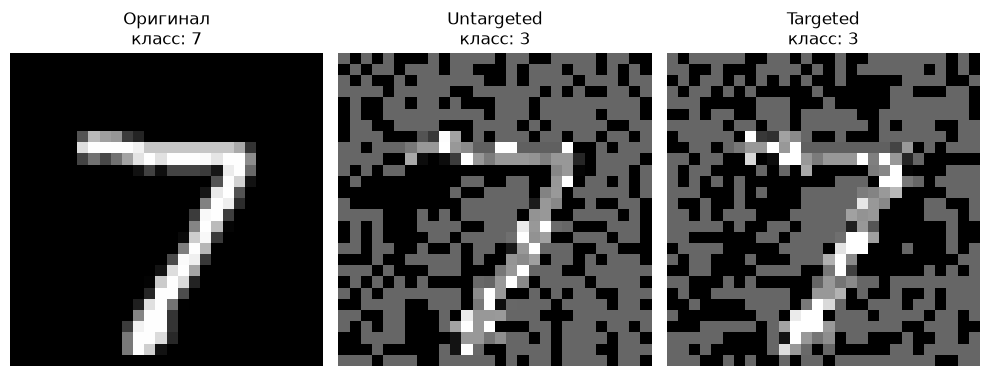

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].imshow(
    x.squeeze().detach().cpu().numpy(),
    cmap="gray"
)
axes[0].set_title(
    f"Оригинал\nкласс: {true_label.item()}"
)
axes[0].axis("off")


axes[1].imshow(
    x_adv_untargeted.squeeze().detach().cpu().numpy(),
    cmap="gray"
)
axes[1].set_title(
    f"Untargeted\nкласс: {untargeted_label}"
)
axes[1].axis("off")


axes[2].imshow(
    x_adv_targeted.squeeze().detach().cpu().numpy(),
    cmap="gray"
)
axes[2].set_title(
    f"Targeted\nкласс: {targeted_label}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

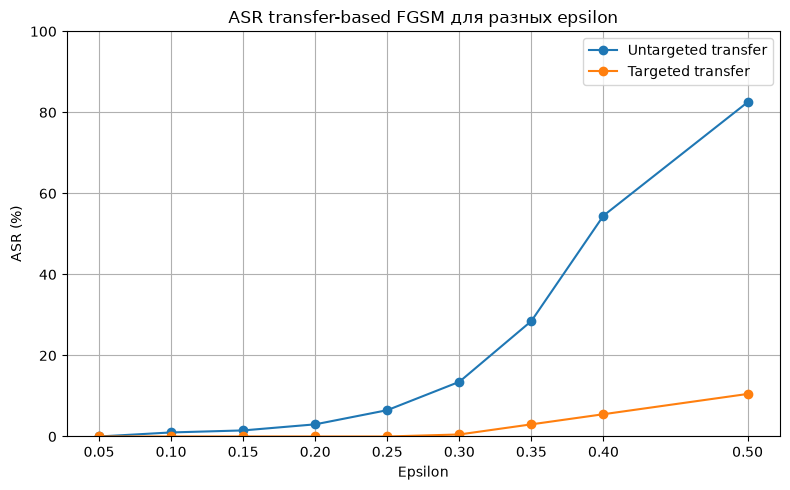

In [63]:
# ============================================================
# C1. ASR для разных epsilon
# ============================================================

epsilons = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]
n_samples = 200

untargeted_asr_values = []
targeted_asr_values = []

substitute_model.eval()

for epsilon in epsilons:

    untargeted_successes = 0
    targeted_successes = 0

    for i in range(n_samples):

        image, label = test_dataset[i]

        x = image.unsqueeze(0).to(device)

        true_label = torch.tensor(
            [label],
            device=device
        )

        target_label = (true_label + 1) % 10

        # -------------------------
        # Untargeted
        # -------------------------

        x_adv = fgsm_attack(
            substitute_model,
            x,
            true_label,
            epsilon=epsilon,
            criterion=crit
        )

        pred = oracle.label(x_adv).item()

        if pred != label:
            untargeted_successes += 1

        # -------------------------
        # Targeted
        # -------------------------

        x_adv = targeted_fgsm_attack(
            substitute_model,
            x,
            target_label,
            epsilon=epsilon,
            criterion=crit
        )

        pred = oracle.label(x_adv).item()

        if pred == target_label.item():
            targeted_successes += 1

    untargeted_asr = (
        100 * untargeted_successes / n_samples
    )

    targeted_asr = (
        100 * targeted_successes / n_samples
    )

    untargeted_asr_values.append(untargeted_asr)
    targeted_asr_values.append(targeted_asr)


# ============================================================
# График
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epsilons,
    untargeted_asr_values,
    marker="o",
    label="Untargeted transfer"
)

plt.plot(
    epsilons,
    targeted_asr_values,
    marker="o",
    label="Targeted transfer"
)

plt.xlabel("Epsilon")
plt.ylabel("ASR (%)")
plt.title("ASR transfer-based FGSM для разных epsilon")

plt.xticks(epsilons)
plt.ylim(0, 100)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## C3
HSJA

In [64]:
def binary_search_boundary(oracle, x_orig,  x_adv, true_label, num_steps=10):
    low = 0.0
    high = 1.0

    for _ in range(num_steps):

        mid = (low + high) / 2

        x_mid = (
            x_orig
            + mid * (x_adv - x_orig)
        )

        x_mid = torch.clamp(
            x_mid,
            0,
            1
        )

        if is_adversarial(
            oracle,
            x_mid,
            true_label
        ):
            high = mid
        else:
            low = mid

    x_boundary = (
        x_orig
        + high * (x_adv - x_orig)
    )

    return torch.clamp(
        x_boundary,
        0,
        1
    ).detach()

In [65]:
def estimate_boundary_direction(oracle, x_boundary, true_label, delta=0.01, n_directions=50):
    noise = torch.randn(
        n_directions,
        *x_boundary.shape[1:],
        device=x_boundary.device
    )

    noise = noise.reshape(
        n_directions,
        -1
    )

    noise_norm = torch.norm(
        noise,
        p=2,
        dim=1,
        keepdim=True
    )

    noise = noise / (
        noise_norm + 1e-12
    )

    x_boundary_batch = x_boundary.repeat(
        n_directions,
        1,
        1,
        1
    )

    x_queries = (
        x_boundary_batch
        + delta * noise.reshape_as(x_boundary_batch)
    )

    x_queries = torch.clamp(
        x_queries,
        0,
        1
    )

    labels = oracle.label(x_queries)

    adversarial = (
        labels != true_label.item()
    )

    signs = torch.where(
        adversarial,
        torch.ones(
            n_directions,
            device=x_boundary.device
        ),
        -torch.ones(
            n_directions,
            device=x_boundary.device
        )
    )

    gradient = (
        signs.view(-1, 1) * noise
    ).mean(dim=0)

    gradient = gradient.reshape_as(x_boundary)

    gradient_norm = torch.norm(
        gradient.reshape(-1),
        p=2
    )

    gradient = gradient / (
        gradient_norm + 1e-12
    )

    return gradient

In [66]:
def hsja_simplified( oracle, x_orig, true_label, x_init, num_steps=30, binary_steps=10, n_directions=50, delta=0.01, step_size=0.1):
    x_adv = x_init.clone().detach()

    history = []

    for iteration in range(num_steps):

        # ----------------------------------------
        # 1. Ищем точку на границе
        # ----------------------------------------

        x_boundary = binary_search_boundary(
            oracle,
            x_orig,
            x_adv,
            true_label,
            num_steps=binary_steps
        )

        # ----------------------------------------
        # 2. Оцениваем направление границы
        # ----------------------------------------

        current_l2 = torch.norm(
            (x_boundary - x_orig).reshape(-1),
            p=2
        ).item()

        current_delta = delta * max(
            current_l2,
            1e-3
        )

        direction = estimate_boundary_direction(
            oracle,
            x_boundary,
            true_label,
            delta=current_delta,
            n_directions=n_directions
        )

        # ----------------------------------------
        # 3. Шаг в направлении
        # ----------------------------------------

        step = step_size * max(
            current_l2,
            1e-3
        )

        candidate = (
            x_boundary
            - step * direction
        )

        candidate = torch.clamp(
            candidate,
            0,
            1
        )

        # ----------------------------------------
        # 4. Проверяем adversarial
        # ----------------------------------------

        if is_adversarial(
            oracle,
            candidate,
            true_label
        ):
            x_adv = candidate
        else:
            # Если направление не сработало,
            # пробуем меньший шаг
            candidate = (
                x_boundary
                - 0.5 * step * direction
            )

            candidate = torch.clamp(
                candidate,
                0,
                1
            )

            if is_adversarial(
                oracle,
                candidate,
                true_label
            ):
                x_adv = candidate
            else:
                x_adv = x_boundary

        current_l2 = torch.norm(
            (x_adv - x_orig).reshape(-1),
            p=2
        ).item()

        history.append(current_l2)

        step_size *= 0.9

    return x_adv.detach(), history

In [67]:
# ============================================================
# C3. HopSkipJumpAttack
# ============================================================

oracle.reset()

x_orig, true_label_value = test_dataset[0]

x_orig = x_orig.unsqueeze(0).to(device)

true_label = torch.tensor(
    [true_label_value],
    device=device
)


# Ищем реальную 3, которую модель классифицирует как 3

x_init = None

for i in range(len(test_dataset)):
    image, label = test_dataset[i]

    if label == 3:
        candidate = image.unsqueeze(0).to(device)

        if oracle.label(candidate).item() == 3:
            x_init = candidate
            break

if x_init is None:
    raise RuntimeError(
        "Не удалось найти изображение 3, которое модель классифицирует как 3."
    )


print(f"Исходный класс: {true_label.item()}")
print(f"Начальный класс: {oracle.label(x_init).item()}")


# Сбрасываем счётчик перед самой атакой
oracle.reset()

start_time = time.time()

x_hsja, hsja_history = hsja_simplified(
    oracle,
    x_orig,
    true_label,
    x_init,
    num_steps=10,
    binary_steps=10,
    n_directions=10,
    delta=0.001,
    step_size=0.1
)

elapsed_time = time.time() - start_time


# Финальная проверка
final_label = oracle.label(x_hsja).item()

success = (
    final_label != true_label.item()
)

l2_norm = torch.norm(
    (x_hsja - x_orig).reshape(-1),
    p=2
).item()

queries = oracle.n_queries


print("\n=== HopSkipJumpAttack ===")
print(f"Финальный класс: {final_label}")
print(f"Успех: {success}")
print(f"L2-норма: {l2_norm:.4f}")
print(f"Запросов: {queries}")
print(f"Время: {elapsed_time:.2f} сек.")

Исходный класс: 7
Начальный класс: 3

=== HopSkipJumpAttack ===
Финальный класс: 3
Успех: True
L2-норма: 5.0275
Запросов: 216
Время: 0.06 сек.


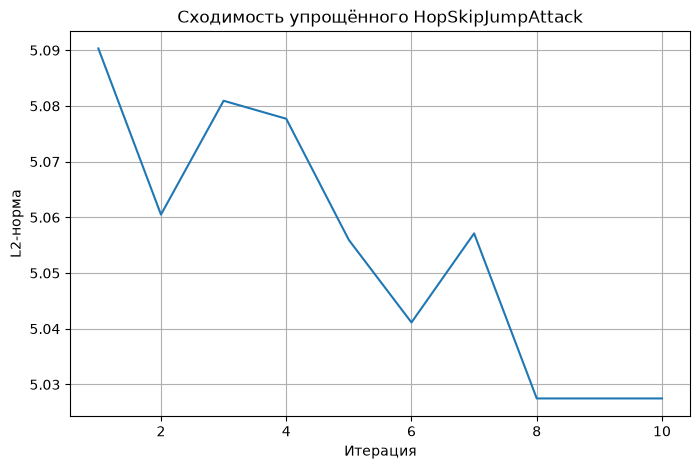

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(hsja_history) + 1),
    hsja_history
)

plt.xlabel("Итерация")
plt.ylabel("L2-норма")
plt.title("Сходимость упрощённого HopSkipJumpAttack")
plt.grid(True)

plt.show()

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Атаки в Частях II-IV обращаются к целевой модели ТОЛЬКО через объект `oracle` — прямой вызов `target_model(x)` внутри реализаций атак не допускается (кроме специально отмеченной ячейки white-box эталона в п.2.3).
- Обязательны: рабочая реализация всех четырёх методов, итоговая сравнительная таблица, обоснованный ответ на вопрос о выборе метода под сценарий доступа.
